# Benchmark Report

This notebook is a read-only report over the outputs the pipeline already produced -- it does **not** call Ollama or re-run any LLM scoring itself, so it works even if Ollama isn't running. It reads two files that `python main.py --audit` and `python main.py --benchmark` already generated:

- `outputs/enriched_facets.csv` -- the 399 facets after cleaning/classification
- `outputs/benchmark_report.json` -- the 10-conversation benchmark results

The one thing this notebook *does* compute fresh is the "most retrieved facets" section near the bottom, which re-runs FAISS retrieval (embedding + similarity search only, no LLM) over the same 10 benchmark conversations to see which facets showed up most often across all of them.

**To run this notebook:** make sure you've already run `python main.py --audit`, `python main.py --embed`, and `python main.py --benchmark` at least once from the project root (so the output files exist), then just Run All cells here.

In [1]:
import json
import sys
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

# Work out the project root regardless of whether Jupyter's cwd is the
# notebooks/ folder or the project root itself, so this cell doesn't break
# depending on how the notebook was launched.
cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_ROOT))

OUTPUTS_DIR = PROJECT_ROOT / "outputs"
BENCHMARK_REPORT_PATH = OUTPUTS_DIR / "benchmark_report.json"
ENRICHED_CSV_PATH = OUTPUTS_DIR / "enriched_facets.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Looking for: {BENCHMARK_REPORT_PATH}")
print(f"Looking for: {ENRICHED_CSV_PATH}")

Project root: C:\ahoum-assignment
Looking for: C:\ahoum-assignment\outputs\benchmark_report.json
Looking for: C:\ahoum-assignment\outputs\enriched_facets.csv


In [2]:
# Load the two source files. Fail loudly with a clear message rather than a
# confusing pandas/json stack trace if the pipeline hasn't been run yet.
if not BENCHMARK_REPORT_PATH.exists():
    raise FileNotFoundError(
        f"{BENCHMARK_REPORT_PATH} not found -- run `python main.py --benchmark` from "
        "the project root first."
    )
if not ENRICHED_CSV_PATH.exists():
    raise FileNotFoundError(
        f"{ENRICHED_CSV_PATH} not found -- run `python main.py --audit` from "
        "the project root first."
    )

with open(BENCHMARK_REPORT_PATH, "r", encoding="utf-8") as f:
    benchmark_report = json.load(f)

enriched_facets = pd.read_csv(ENRICHED_CSV_PATH)

print(f"Loaded benchmark report: {len(benchmark_report['cases'])} conversations")
print(f"Loaded enriched facets: {len(enriched_facets)} rows")

Loaded benchmark report: 10 conversations
Loaded enriched facets: 399 rows


## 1. Benchmark outcome summary

Every reference facet from the 10 benchmark conversations gets graded into one bucket by `src/benchmark.py`:

- **exact_agreement** -- system's score matched my hand-labeled reference score exactly
- **close_agreement** -- system's score was off by 1 from my reference (still counted as a success)
- **correct_abstention** -- I expected the system to abstain (`insufficient_evidence`), and it did
- **correct_abstention_not_retrieved** -- I expected abstention on a medical/spiritual/malformed facet, and it correctly never even got retrieved (the two-layer safety filter working as designed)
- **retrieval_miss** -- I expected a real score, but the facet was never retrieved by FAISS in the first place, so the LLM never got a chance to score it
- **disagreement / incorrect_abstention / incorrect_overconfident_score / SAFETY_VIOLATION_*** -- other failure modes (should be rare to absent; a `SAFETY_VIOLATION_*` here would mean a medical/spiritual facet got scored, which never happened in our runs)

In [3]:
outcome_counts = benchmark_report["outcome_counts"]

# Order the rows roughly best -> worst so the table reads like a scorecard,
# same ordering convention benchmark.py uses when it prints to the terminal.
outcome_order = [
    "exact_agreement", "close_agreement", "correct_abstention",
    "correct_abstention_not_retrieved", "disagreement", "incorrect_abstention",
    "incorrect_overconfident_score", "retrieval_miss",
    "SAFETY_VIOLATION_scored_non_observable_facet",
]

summary_rows = []
for outcome in outcome_order:
    if outcome in outcome_counts:
        summary_rows.append({"outcome": outcome, "count": outcome_counts[outcome]})
for outcome, count in outcome_counts.items():
    if outcome not in outcome_order:
        summary_rows.append({"outcome": outcome, "count": count})

summary_df = pd.DataFrame(summary_rows)
total_facets = summary_df["count"].sum()
summary_df["pct_of_total"] = (summary_df["count"] / total_facets * 100).round(1)

good_outcomes = {"exact_agreement", "close_agreement", "correct_abstention", "correct_abstention_not_retrieved"}
n_good = summary_df.loc[summary_df["outcome"].isin(good_outcomes), "count"].sum()
print(f"Overall: {n_good}/{total_facets} reference facets handled correctly ({n_good/total_facets*100:.0f}%)")

summary_df

Overall: 18/30 reference facets handled correctly (60%)


,outcome,count,pct_of_total
0,exact_agreement,4,13.3
1,close_agreement,3,10.0
2,correct_abstention,3,10.0
3,correct_abstention_not_retrieved,8,26.7
4,retrieval_miss,12,40.0


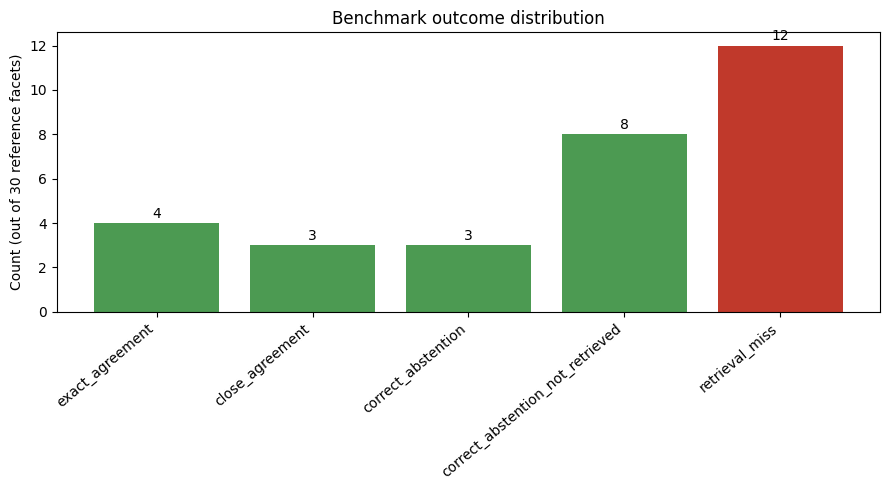

In [4]:
# Bar chart of outcome distribution. Color good outcomes green-ish, failure
# modes red/orange, so the chart reads at a glance.
good = {"exact_agreement", "close_agreement", "correct_abstention", "correct_abstention_not_retrieved"}
colors = ["#4c9a52" if o in good else "#c0392b" for o in summary_df["outcome"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(summary_df["outcome"], summary_df["count"], color=colors)
ax.set_ylabel("Count (out of 30 reference facets)")
ax.set_title("Benchmark outcome distribution")
ax.set_xticks(range(len(summary_df)))
ax.set_xticklabels(summary_df["outcome"], rotation=40, ha="right")
for bar, count in zip(bars, summary_df["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, str(count), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 2. Facet category breakdown

`src/audit.py` sorts all 399 raw facets into 7 categories. Only `personality_trait`, `cognitive_ability`, and `behavioral_tendency` are `conversation_observable = True` -- the rest (`medical_biological`, `spiritual_esoteric`, `social_demographic`, `header_or_malformed`) are structurally excluded from retrieval, which is the audit-time half of the two-layer safety design described in `docs/DECISIONS.md`.

In [5]:
category_counts = (
    enriched_facets.groupby("category")
    .agg(count=("facet_normalized", "size"), observable=("conversation_observable", "first"))
    .reindex([
        "personality_trait", "cognitive_ability", "behavioral_tendency",
        "medical_biological", "spiritual_esoteric", "social_demographic",
        "header_or_malformed",
    ])
    .reset_index()
)
category_counts["observable"] = category_counts["observable"].map({True: "Yes", False: "No"})

print(f"Total facets: {len(enriched_facets)}")
print(f"Observable (usable by the pipeline): {int(enriched_facets['conversation_observable'].sum())}")
print(f"Not observable (never reachable by retrieval): {int((~enriched_facets['conversation_observable']).sum())}")

category_counts

Total facets: 399
Observable (usable by the pipeline): 322
Not observable (never reachable by retrieval): 77


,category,count,observable
0,personality_trait,293,Yes
1,cognitive_ability,13,Yes
2,behavioral_tendency,16,Yes
3,medical_biological,8,No
4,spiritual_esoteric,31,No
5,social_demographic,6,No
6,header_or_malformed,32,No


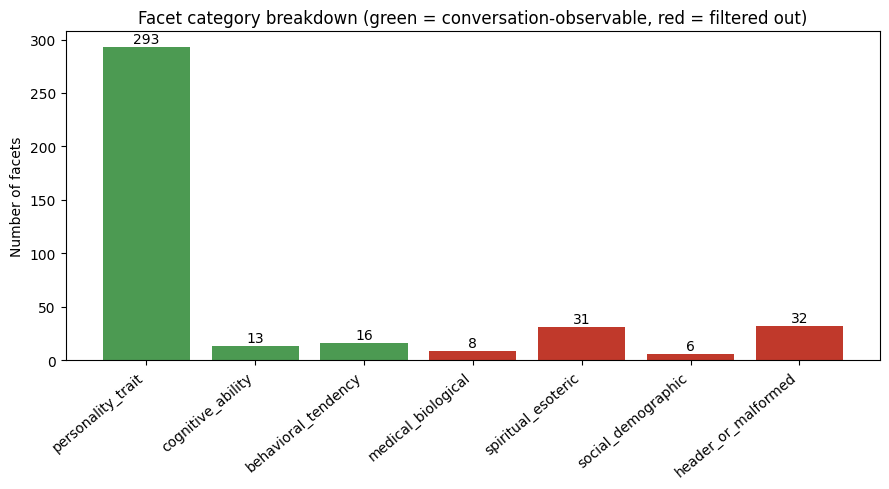

In [6]:
colors = ["#4c9a52" if o == "Yes" else "#c0392b" for o in category_counts["observable"]]

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(category_counts["category"], category_counts["count"], color=colors)
ax.set_ylabel("Number of facets")
ax.set_title("Facet category breakdown (green = conversation-observable, red = filtered out)")
ax.set_xticks(range(len(category_counts)))
ax.set_xticklabels(category_counts["category"], rotation=40, ha="right")
for bar, count in zip(bars, category_counts["count"]):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1, str(count), ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Most-retrieved facets across the benchmark conversations

The benchmark report only stores *how many* facets were retrieved per conversation, not the full list, so this section re-runs `retrieve_relevant_facets()` (FAISS search only -- no LLM, no Ollama needed) over the same 10 benchmark conversations to see which facets came up most often. A facet showing up across many different conversation types suggests it's either a very common/general trait or possibly sitting in an unusually "central" part of the embedding space -- either is useful to know when sanity-checking retrieval quality.

In [7]:
from src.embeddings import retrieve_relevant_facets
from src.benchmark import BENCHMARK_CASES

TOP_K = 40  # matches src/pipeline.py's TOP_K_DEFAULT

retrieval_counter = Counter()
per_conversation_retrieved = {}

for case in BENCHMARK_CASES:
    try:
        retrieved = retrieve_relevant_facets(case["conversation"], top_k=TOP_K)
    except Exception as e:
        print(f"Could not retrieve for case {case['id']} ({case['type']}): {e}")
        continue
    names = [r["facet_normalized"] for r in retrieved]
    per_conversation_retrieved[case["type"]] = names
    retrieval_counter.update(names)

print(f"Ran retrieval over {len(per_conversation_retrieved)} conversations at top_k={TOP_K}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Ran retrieval over 10 conversations at top_k=40


In [8]:
top10 = retrieval_counter.most_common(10)
top10_df = pd.DataFrame(top10, columns=["facet", "times_retrieved"])
top10_df["out_of_conversations"] = f"{len(per_conversation_retrieved)}"
top10_df

,facet,times_retrieved,out_of_conversations
0,Control over situations,7,10
1,Desperation,6,10
2,Burnout Symptoms,6,10
3,Discernment practice hours / week,5,10
4,General Mood and Attitude,5,10
5,Depression Symptoms,5,10
6,Volunteer Work,4,10
7,Risktaking,4,10
8,Boredom Susceptibility,4,10
9,Encouraging participation,4,10


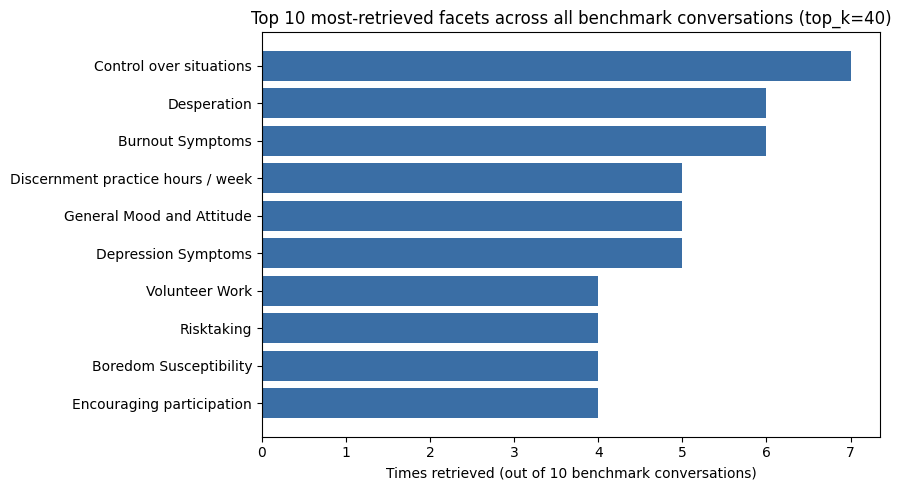

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top10_df["facet"][::-1], top10_df["times_retrieved"][::-1], color="#3a6ea5")
ax.set_xlabel(f"Times retrieved (out of {len(per_conversation_retrieved)} benchmark conversations)")
ax.set_title(f"Top 10 most-retrieved facets across all benchmark conversations (top_k={TOP_K})")
plt.tight_layout()
plt.show()

## 4. Takeaways

- **Safety held up completely**: `SAFETY_VIOLATION_scored_non_observable_facet` is 0 (or absent) above -- no medical, spiritual, or malformed facet was ever scored across the whole benchmark, across every conversation including the ones specifically written to try to trigger it (the medical-trap and spiritual-trap cases).
- **Retrieval miss is the dominant failure mode**, not scoring quality -- when the system got a facet wrong, it was almost always because that facet never made it into the candidate list FAISS handed to the LLM, not because the LLM scored it incorrectly. See `docs/DEBUGGING.md` #1 and `docs/DECISIONS.md` #1 for the full investigation into why (short version: it's the generic templated embedding text, not the `top_k` cutoff).
- The most-retrieved facets above are worth a manual sanity check -- if the same handful of facets show up for almost every conversation regardless of topic, that's a sign they may be sitting in a "generic" part of embedding space that FAISS defaults to when nothing else is a strong match, rather than genuinely being the most relevant facet each time.